In [22]:
import pandas as pd

df = pd.read_csv(r"C:\Users\chyj2\OneDrive\Desktop\baltimore-crime-analytics\data\raw\baltimore_crime_raw.csv")


C:\Users\chyj2\AppData\Local\Temp\ipykernel_24204\3166100755.py:3: DtypeWarning: Columns (5,7,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\chyj2\OneDrive\Desktop\baltimore-crime-analytics\data\raw\baltimore_crime_raw.csv")


In [23]:
df.head()

,RowID,CCNumber,CrimeDateTime,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,...,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
0,1,14I10336,8/29/2014 12:00,5A,BURGLARY,NaN,NaN,835.0,M,52.0,...,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1,-76.660731,39.288352
1,2,14H13075,8/29/2014 23:45,4E,COMMON ASSAULT,NaN,NaN,515.0,F,24.0,...,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1,-76.607897,39.335514
2,3,14H13066,8/29/2014 23:10,6G,LARCENY,NaN,NaN,114.0,F,44.0,...,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1,-76.618255,39.292553
3,4,14I00593,8/29/2014 7:00,6J,LARCENY,NaN,NaN,732.0,NaN,NaN,...,WESTERN,NaN,PARKVIEW/WOODBROOK,39.316814,-76.649890,"(39.316813840390076,-76.649889876952656)",STREET,1,-76.649890,39.316814
4,5,14H13360,8/29/2014 23:30,6G,LARCENY,NaN,NaN,213.0,F,26.0,...,SOUTHEAST,NaN,FELLS POINT,39.280805,-76.594750,"(39.28080478810265,-76.594749640946659)",BAR,1,-76.594750,39.280805


In [87]:
#turn column header to lowercase
df.columns = (df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_"))

In [113]:
# List of all the columns you want to remove
columns_to_drop = [
    'rowid', 'ccnumber', 'crimecode', 'inside_outside', 
    'post', 'location', 'new_district', 'latitude', 
    'longitude', 'geolocation', 'x', 'y', 'total_incidents',
]

# Drop them from the dataframe
# Using errors='ignore' ensures Python doesn't panic if one of these was already dropped earlier
df = df.drop(columns=columns_to_drop, errors='ignore')

# Verify the final list of columns
print("Columns remaining after drop:")
print(df.columns.tolist())

# Check the new, much lighter dataset shape
print(f"\nNew Dataset Shape: {df.shape}")

Columns remaining after drop:
['crime_date', 'description', 'weapon', 'gender', 'age', 'race', 'old_district', 'neighborhood', 'premisetype', 'year', 'month', 'month_name', 'day_of_week']

New Dataset Shape: (639085, 13)


In [114]:
# Rename 'crimedatetime' to 'crime_date'
df.rename(columns={'crimedatetime': 'crime_date'}, inplace=True)

# Verify the change
print(df.columns.tolist())


['crime_date', 'description', 'weapon', 'gender', 'age', 'race', 'old_district', 'neighborhood', 'premisetype', 'year', 'month', 'month_name', 'day_of_week']


In [115]:
# Convert the date column to actual datetime objects
df["crime_date"] = pd.to_datetime(df["crime_date"], errors="coerce")

# Extract time features for our dashboards
df["year"] = df["crime_date"].dt.year
df["month"] = df["crime_date"].dt.month
df["month_name"] = df["crime_date"].dt.month_name()
df["day_of_week"] = df["crime_date"].dt.day_name()

# Look at the new columns
display(df[["crime_date", "year", "month_name", "day_of_week"]].head())

,crime_date,year,month_name,day_of_week
0,2014-08-29 12:00:00,2014,August,Friday
1,2014-08-29 23:45:00,2014,August,Friday
2,2014-08-29 23:10:00,2014,August,Friday
3,2014-08-29 07:00:00,2014,August,Friday
4,2014-08-29 23:30:00,2014,August,Friday


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639085 entries, 0 to 644736
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   crime_date    639085 non-null  datetime64[ns]
 1   description   639085 non-null  object        
 2   weapon        639085 non-null  object        
 3   gender        639085 non-null  object        
 4   age           639085 non-null  float64       
 5   race          639085 non-null  object        
 6   old_district  639085 non-null  object        
 7   neighborhood  639085 non-null  object        
 8   premisetype   639085 non-null  object        
 9   year          639085 non-null  int32         
 10  month         639085 non-null  int32         
 11  month_name    639085 non-null  object        
 12  day_of_week   639085 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(2), object(9)
memory usage: 63.4+ MB


In [117]:
# 1. Identify and Remove Duplicates
initial_rows = len(df)
df = df.drop_duplicates()

# If there are duplicate unique row IDs, keep only the first one
if 'rowid' in df.columns:
    df = df.drop_duplicates(subset=['rowid'])
    
print(f"Dropped {initial_rows - len(df)} duplicate rows.")

Dropped 0 duplicate rows.


In [118]:
# 3. Fix Structural Errors (Whitespace and inconsistent casing)
cols_to_strip = ['description', 'gender', 'race', 'neighborhood', 'premisetype']

for col in cols_to_strip:
    if col in df.columns:
        # Remove leading/trailing spaces and make text Title Case
        df[col] = df[col].astype(str).str.strip().str.title()

In [119]:
# Standardize gender formatting if 'M'/'F' abbreviations exist
if 'gender' in df.columns:
    df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'U': 'Unknown'})

print("Text columns standardized.")
display(df[['description', 'gender', 'race']].head())

Text columns standardized.


,description,gender,race
0,Burglary,Male,Unknown
1,Common Assault,Female,Black_Or_African_American
2,Larceny,Female,Black_Or_African_American
3,Larceny,Nan,Unknown
4,Larceny,Female,White


In [134]:
# 1. Missing Data Percentage
print("--- Percentage of Missing Data by Column ---")
missing_pct = (df.isnull().sum() / len(df)) * 100
display(missing_pct[missing_pct > 0].sort_values(ascending=False).round(2).astype(str) + '%')

--- Percentage of Missing Data by Column ---


Series([], dtype: object)

In [121]:
# 1. Drop the columns that are mostly empty
columns_to_drop = ['inside_outside', 'new_district', 'ethnicity']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [122]:
# 3. Fill categorical missing values with "Unknown"
categorical_cols = ['gender', 'race', 'old_district', 'premisetype', 'neighborhood',  ]
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

In [123]:
# 4. Fill missing Age with the median age
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

In [124]:
# 5. For 'weapon', fill with "None" so we know no weapon was reported
df['weapon'] = df['weapon'].fillna('None')

In [125]:
print(f"New row count after cleaning: {len(df)}")
print("\nMissing values remaining:")
display(df.isnull().sum())

New row count after cleaning: 639085

Missing values remaining:


crime_date      0
description     0
weapon          0
gender          0
age             0
race            0
old_district    0
neighborhood    0
premisetype     0
year            0
month           0
month_name      0
day_of_week     0
dtype: int64

In [126]:
# 2. Handle Remaining Missing Values
# Drop the 6 rows missing 'crime_date' and temporal features
df = df.dropna(subset=['crime_date'])
print(f"Rows remaining after dropping missing dates: {len(df)}")

Rows remaining after dropping missing dates: 639085


In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional style for portfolio charts
sns.set_theme(style="whitegrid")

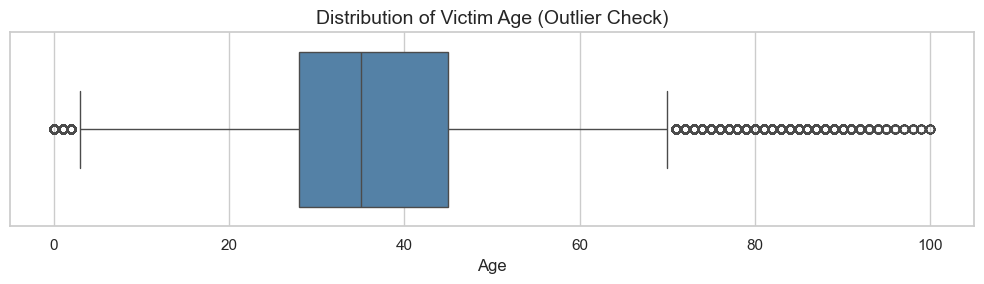

In [128]:
plt.figure(figsize=(10, 3))

# Create a horizontal boxplot for the 'age' column
sns.boxplot(x=df['age'], color='steelblue')

plt.title('Distribution of Victim Age (Outlier Check)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.tight_layout()
plt.show()

--- Outlier Count by Variable (IQR Method) ---
            age: 17,259 outliers
           year: 119 outliers
          month: 0 outliers

--- Generating Boxplot Grid ---


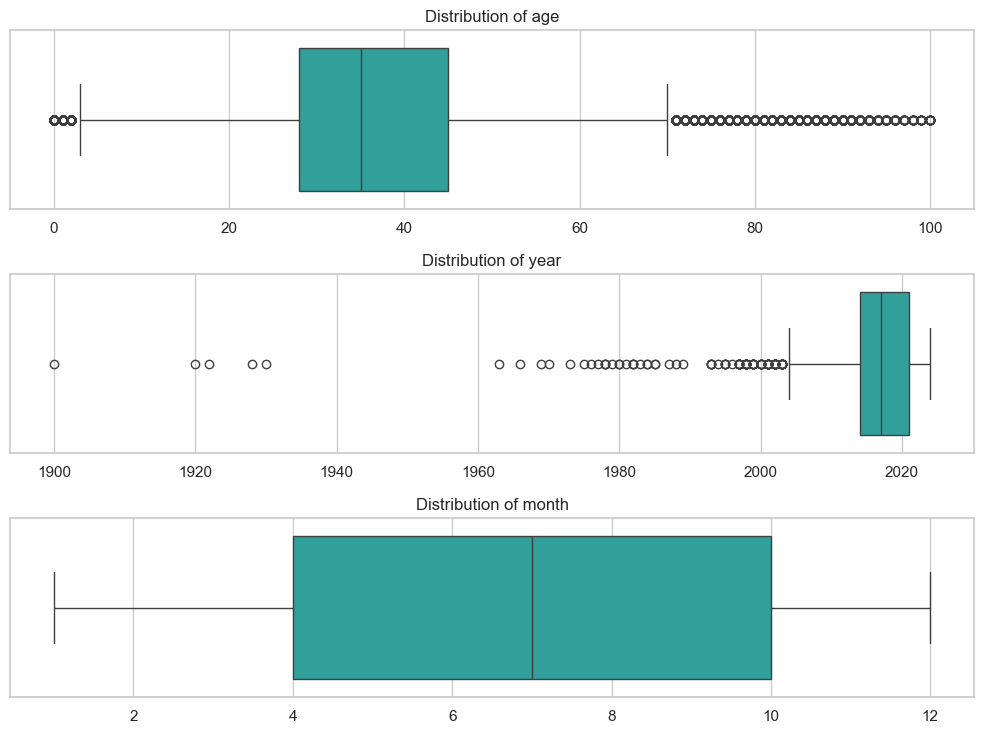

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Isolate only the numerical columns
numerical_cols = df.select_dtypes(include=['int32', 'int64', 'float64']).columns

print("--- Outlier Count by Variable (IQR Method) ---")

# 1. Mathematical Detection (IQR Method)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the bounds
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col:>15}: {outlier_count:,} outliers")

print("\n--- Generating Boxplot Grid ---")

# 2. Visual Detection (Stacked Boxplots)
num_plots = len(numerical_cols)
plt.figure(figsize=(10, 2.5 * num_plots))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_plots, 1, i)
    sns.boxplot(x=df[col], color='lightseagreen')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [130]:
# 1. Look at the weird years
print("--- Crime Counts by Year ---")
print(df['year'].value_counts().sort_index())

# 2. Filter out the typos (Adjust the years below based on what prints above)
# Assuming the valid data is mostly from 2011 to 2024
valid_start_year = 2011 
valid_end_year = 2024 

initial_rows = len(df)
df = df[(df['year'] >= valid_start_year) & (df['year'] <= valid_end_year)]

print(f"\nDropped {initial_rows - len(df)} rows with impossible years.")

--- Crime Counts by Year ---
year
1900        1
1920        1
1922        1
1928        1
1930        1
1963        1
1966        1
1969        1
1970        1
1973        1
1975        1
1976        1
1977        1
1978        3
1979        1
1980        2
1981        1
1982        3
1983        1
1984        2
1985        2
1987        1
1988        1
1989        1
1993        4
1994        1
1995        4
1996        1
1997        9
1998       12
1999        8
2000        6
2001       11
2002       20
2003       12
2004        5
2005        3
2006        4
2007       13
2008       12
2009       15
2010       27
2011    48318
2012    47575
2013    47721
2014    44899
2015    47624
2016    48203
2017    51918
2018    48298
2019    46352
2020    36104
2021    36775
2022    41062
2023    50310
2024    43728
Name: count, dtype: int64

Dropped 198 rows with impossible years.


In [133]:
# Save the cleaned data to a CSV file
df.to_csv(r"C:\Users\chyj2\OneDrive\Desktop\baltimore-crime-analytics\data\cleaned\cleaned_data_crime.csv", index=False)

In [135]:
import os
print(os.getcwd())

C:\Users\chyj2
